# ✈️ Previsão de Atrasos de Chegada de Voos (2015)

## Objetivo
Construir um modelo de **regressão supervisionado** capaz de prever o atraso de chegada (`ARRIVAL_DELAY`) de voos domésticos nos EUA, utilizando apenas informações disponíveis **antes da decolagem** (sem data leakage).

## Metodologia
1. **Feature Engineering** — criação de features históricas, temporais e operacionais
2. **Modelagem** — comparação entre Regressão Linear (Ridge), Random Forest e XGBoost
3. **Avaliação** — RMSE no conjunto de validação + análise de erros extremos

---
> **Dataset:** [2015 Flight Delays and Cancellations (Kaggle)](https://www.kaggle.com/datasets/usdot/flight-delays)  
> **Métrica principal:** RMSE (Root Mean Squared Error) em minutos


## 1. Configuração do Ambiente e Carregamento dos Dados

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge

import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\Pedro\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
df = pd.read_csv("flights.csv")

C:\Users\Pedro\AppData\Local\Temp\ipykernel_42264\1505972477.py:1: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("flights.csv")


In [3]:
df = df[df["CANCELLED"]==0]

## 2. Feature Engineering

O Feature Engineering é a etapa mais crítica do pipeline. Seguimos a premissa de que **o modelo só pode usar informações conhecidas no momento do agendamento do voo** — qualquer informação gerada durante ou após a operação do voo representaria *data leakage*.

### Estratégia adotada

| Grupo | Features | Descrição |
|-------|----------|-----------|
| **Médias históricas (expanding)** | `EXP_MEAN_ARR_DELAY_*` | Média acumulada do atraso por companhia, rota, aeroporto, dia da semana e mês — usando apenas o passado (`shift(1)`) |
| **Temporais** | `PART_OF_DAY`, `IS_WEEKEND`, `SEASON`, `IS_HOLIDAY` | Padrões cíclicos e sazonais |
| **Operacionais** | `ORIGIN_CONGESTION`, `DESTINATION_CONGESTION`, `ROUTE_POPULARITY` | Pressão operacional nos aeroportos |
| **Cascata de atrasos** | `PREVIOUS_FLIGHT_DELAY`, `BACK_TO_BACK_FLIGHTS` | Efeito de atraso propagado pela aeronave anterior |

> **Prevenção de leakage:** todas as médias expandidas usam `.shift(1)` para garantir que apenas dados históricos são utilizados.


In [4]:
df["SCHEDULED_ARRIVAL_TIME"] = (
    pd.to_datetime(
        df["SCHEDULED_ARRIVAL"]
        .fillna(0)
        .astype(int)
        .astype(str)
        .str.zfill(4),
        format="%H%M",
        errors="coerce"
    )
    .dt.time
)

df["DEPARTURE_TIME"] = (
    pd.to_datetime(
        df["DEPARTURE_TIME"]
        .fillna(0)
        .astype(int)
        .astype(str)
        .str.zfill(4),
        format="%H%M",
        errors="coerce"
    )
    .dt.time
)

In [5]:
df = df.sort_values(['YEAR', 'MONTH', 'DAY', 'SCHEDULED_DEPARTURE'])

### 2.1 Médias Históricas Expandidas (Expanding Mean)

Para cada grupo relevante, calculamos a média acumulada do atraso de chegada ao longo do tempo — deslocada em 1 posição para não vazar o futuro.


In [6]:
df['EXP_MEAN_ARR_DELAY_AIRLINE'] = (
    df.groupby('AIRLINE')['ARRIVAL_DELAY']
    .apply(lambda x: x.expanding().mean().shift(1))
    .reset_index(level=0, drop=True)
)

df['EXP_MEAN_ARR_DELAY_DAY_OF_WEEK'] = (
    df.groupby('DAY_OF_WEEK')['ARRIVAL_DELAY']
    .apply(lambda x: x.expanding().mean().shift(1))
    .reset_index(level=0, drop=True)
)

df['EXP_MEAN_ARR_DELAY_ORIGIN_AIRPORT'] = (
    df.groupby('ORIGIN_AIRPORT')['ARRIVAL_DELAY']
    .apply(lambda x: x.expanding().mean().shift(1))
    .reset_index(level=0, drop=True)
)

df['EXP_MEAN_ARR_DELAY_DESTINATION_AIRPORT'] = (
    df.groupby('DESTINATION_AIRPORT')['ARRIVAL_DELAY']
    .apply(lambda x: x.expanding().mean().shift(1))
    .reset_index(level=0, drop=True)
)

df['EXP_MEAN_ARR_DELAY_MONTH'] = (
    df.groupby('MONTH')['ARRIVAL_DELAY']
    .apply(lambda x: x.expanding().mean().shift(1))
    .reset_index(level=0, drop=True)
)

df['EXP_MEAN_ARR_DELAY_ROUTE'] = (
    df.groupby(['DESTINATION_AIRPORT','ORIGIN_AIRPORT'])['ARRIVAL_DELAY']
    .apply(lambda x: x.expanding().mean().shift(1))
    .reset_index(drop=True)
)

### 2.2 Criação da Coluna de Datetime de Partida e Hora de Saída


In [7]:
def format_time(time_int):
    if pd.isnull(time_int): return np.nan
    if time_int == 2400: time_int = 0
    time_str = str(int(time_int)).zfill(4)
    return f"{time_str[:2]}:{time_str[2:]}:00"

# Criar coluna de data e hora para ordenação e cálculos temporais
df['SCHEDULED_DEPARTURE_DT'] = pd.to_datetime(
    df['YEAR'].astype(str) + '-' + df['MONTH'].astype(str) + '-' + df['DAY'].astype(str) + ' ' + 
    df['SCHEDULED_DEPARTURE'].apply(format_time)
)

In [8]:
df["SCHEDULED_DEPARTURE"] = df["SCHEDULED_DEPARTURE"].astype(str).apply(lambda x: '0'+x if len(x)==3 else x)
df["SCHEDULED_DEPARTURE"] = df["SCHEDULED_DEPARTURE"].astype(str).apply(lambda x: '00'+x if len(x)==2 else x)
df["SCHEDULED_DEPARTURE"] = df["SCHEDULED_DEPARTURE"].astype(str).apply(lambda x: '000'+x if len(x)==1 else x)

In [9]:
df["DEPARTURE_HOUR"] = df["SCHEDULED_DEPARTURE"].apply(lambda x: str(x)[:2]).astype(int)

### 2.3 Features Temporais e Operacionais

Construímos features que capturam padrões sazonais, congestionamento dos aeroportos e o efeito cascata de atrasos consecutivos na mesma aeronave.


In [10]:
# 1. PART_OF_DAY
df['PART_OF_DAY'] = pd.cut(df['DEPARTURE_HOUR'], 
                           bins=[-1, 5, 12, 17, 23], 
                           labels=['Madrugada', 'Manhã', 'Tarde', 'Noite'])

# 2. IS_WEEKEND
# DAY_OF_WEEK: 1=Seg, 7=Dom (ou 0=Seg, 6=Dom dependendo da fonte, ajuste se necessário)
df['IS_WEEKEND'] = df['DAY_OF_WEEK'].apply(lambda x: 1 if x in [6, 7] else 0)

# 3. SEASON (Hemisfério Norte - Ajuste se necessário)
df['SEASON'] = df['MONTH'].apply(lambda x: 
    'Inverno' if x in [12, 1, 2] else 
    'Primavera' if x in [3, 4, 5] else 
    'Verão' if x in [6, 7, 8] else 'Outono')

# 4. IS_HOLIDAY (Exemplo com datas fixas dos EUA - O ideal é usar a lib 'holidays')
holidays = ['2015-01-01', '2015-07-04', '2015-11-26', '2015-12-25'] # Adicione mais
df['IS_HOLIDAY'] = df['SCHEDULED_DEPARTURE_DT'].dt.date.astype(str).isin(holidays).astype(int)

# --- PREVENÇÃO DE LEAKAGE: ORDENAÇÃO ---
# Para as próximas features, a ordem cronológica é essencial
df = df.sort_values(['TAIL_NUMBER', 'SCHEDULED_DEPARTURE_DT'])

# 5 & 6. CONGESTION (ORIGIN e DESTINATION)
# Quantos voos partem/chegam na mesma hora/aeroporto?
# Usamos SCHEDULED para evitar leakage (informação conhecida antes do voo)
df['ORIGIN_CONGESTION'] = df.groupby(['ORIGIN_AIRPORT', 'YEAR', 'MONTH', 'DAY', 'DEPARTURE_HOUR'])['YEAR'].transform('count')
df['DESTINATION_CONGESTION'] = df.groupby(['DESTINATION_AIRPORT', 'YEAR', 'MONTH', 'DAY', 'DEPARTURE_HOUR'])['YEAR'].transform('count')

# 7. ROUTE_POPULARITY (Expanding Count)
# Evita leakage usando apenas o que aconteceu "até agora"
df['ROUTE'] = df['ORIGIN_AIRPORT'].astype(str) + '-' + df['DESTINATION_AIRPORT'].astype(str)
df['ROUTE_POPULARITY'] = df.groupby('ROUTE').cumcount()

# 8. BACK_TO_BACK_FLIGHTS (Quantos voos o avião já fez no dia)
df['BACK_TO_BACK_FLIGHTS'] = df.groupby(['TAIL_NUMBER', 'YEAR', 'MONTH', 'DAY']).cumcount()

# 9. PREVIOUS_FLIGHT_DELAY (O segredo do efeito cascata)
# Shift(1) move o atraso do voo anterior para a linha do voo atual do mesmo avião
df['PREVIOUS_FLIGHT_DELAY'] = df.groupby('TAIL_NUMBER')['ARRIVAL_DELAY'].shift(1)

# Se o avião está no seu primeiro voo do dia, o atraso anterior deve ser 0 ou NaN?
# Vamos preencher com 0 assumindo que ele começou "limpo"
df['PREVIOUS_FLIGHT_DELAY'] = df['PREVIOUS_FLIGHT_DELAY'].fillna(0)

# Limpeza final das auxiliares
# df.drop(columns=['ROUTE', 'DEPARTURE_HOUR'], inplace=True)

#### Validação: Efeito Cascata de Atrasos

Abaixo verificamos se a feature `PREVIOUS_FLIGHT_DELAY` está sendo calculada corretamente — o atraso do voo anterior deve aparecer na linha do próximo voo do mesmo avião.


In [11]:
df[['TAIL_NUMBER','SCHEDULED_DEPARTURE_DT','DEPARTURE_TIME','ARRIVAL_DELAY',"BACK_TO_BACK_FLIGHTS",'PREVIOUS_FLIGHT_DELAY']].head(20)

,TAIL_NUMBER,SCHEDULED_DEPARTURE_DT,DEPARTURE_TIME,ARRIVAL_DELAY,BACK_TO_BACK_FLIGHTS,PREVIOUS_FLIGHT_DELAY
3052236,7819A,2015-07-10 19:30:00,19:42:00,3.0,0,0.0
3055380,7819A,2015-07-11 06:00:00,05:56:00,-7.0,0,3.0
3059072,7819A,2015-07-11 09:40:00,09:44:00,-25.0,1,-7.0
3061230,7819A,2015-07-11 12:00:00,11:56:00,-15.0,2,-25.0
3064226,7819A,2015-07-11 15:20:00,15:21:00,NaN,3,-15.0
3065979,7819A,2015-07-11 17:20:00,19:44:00,124.0,4,0.0
3066890,7819A,2015-07-11 18:25:00,20:30:00,104.0,5,124.0
3068892,7819A,2015-07-11 21:10:00,22:45:00,88.0,6,104.0
3071094,7819A,2015-07-12 06:55:00,06:51:00,-10.0,0,88.0
3073040,7819A,2015-07-12 08:45:00,08:39:00,-9.0,1,-10.0


### 2.4 Encoding de Variáveis Categóricas Ordinais

`PART_OF_DAY` e `SEASON` são convertidas para inteiros preservando a ordem cíclica, evitando a introdução de alta cardinalidade.


In [12]:
part_of_day_map = {
    'Madrugada': 0,
    'Manhã': 1,
    'Tarde': 2,
    'Noite': 3
}

# Mapeamento para SEASON (seguindo o ciclo anual, começando pelo inverno ou primavera)
season_map = {
    'Inverno': 0,
    'Primavera': 1,
    'Verão': 2,
    'Outono': 3
}

# Aplicando a transformação
df['PART_OF_DAY_NUM'] = df['PART_OF_DAY'].map(part_of_day_map).astype(int)
df['SEASON_NUM'] = df['SEASON'].map(season_map).astype(int)

## 3. Preparação dos Dados para Modelagem

### 3.1 Seleção de Features e Target


In [13]:
features = ['EXP_MEAN_ARR_DELAY_AIRLINE','EXP_MEAN_ARR_DELAY_DAY_OF_WEEK','EXP_MEAN_ARR_DELAY_ORIGIN_AIRPORT',
           'EXP_MEAN_ARR_DELAY_DESTINATION_AIRPORT','EXP_MEAN_ARR_DELAY_MONTH','EXP_MEAN_ARR_DELAY_ROUTE','DISTANCE',
           "PART_OF_DAY_NUM", "IS_WEEKEND", "IS_HOLIDAY", "SEASON_NUM", "ORIGIN_CONGESTION", 
    "DESTINATION_CONGESTION", "ROUTE_POPULARITY", "BACK_TO_BACK_FLIGHTS", "PREVIOUS_FLIGHT_DELAY"]

target = 'ARRIVAL_DELAY'

### 3.2 Otimização de Tipos e Remoção de Nulos

Convertemos `float64` → `float32` e `int64` → `int32` para reduzir uso de memória e remover linhas com valores ausentes nas colunas relevantes.


In [14]:
for col in features + [target]:
    if df[col].dtype == 'float64':
        df[col] = df[col].astype('float32')
    elif df[col].dtype == 'int64':
        df[col] = df[col].astype('int32')

In [15]:
cols_to_check = features + [target]
df_clean = df.dropna(subset=cols_to_check)

X = df_clean[features]
y = df_clean[target]

### 3.3 Estratégia de Divisão dos Dados

Utilizamos uma **divisão em três conjuntos**:

```
Dataset completo (≈5.6M linhas)
│
├─ 80% Working Set ──┬─ 80% Train  (≈3.6M linhas)  → treinar o modelo final
│                    └─ 20% Test   (≈898K linhas)   → avaliar desempenho
│
└─ 20% Holdout (≈1.1M linhas) → reservado para avaliação final independente
```

Além disso, um subconjunto de **100.000 amostras** é usado para o `GridSearchCV` — garantindo viabilidade computacional sem sacrificar a representatividade.


In [16]:
# 2. First Split: Set aside 20% as the final holdout set
# 80% working data (X_work, y_work), 20% holdout data (X_holdout, y_holdout)
X_work, X_holdout, y_work, y_holdout = train_test_split(
    X, y, test_size=0.20, random_state=42
)

In [17]:
# 3. Second Split: Of the 80% working data, split into 80% train and 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X_work, y_work, test_size=0.20, random_state=42
)

In [18]:
df_search = df_clean.sample(n=min(100000, len(df_clean)), random_state=42)
X_search = df_search[features]
y_search = df_search[target]

In [19]:
X_train.shape

(3594047, 16)

## 4. Modelagem e Seleção de Hiperparâmetros

### 4.1 Pipelines e GridSearchCV

Três modelos foram testados com `GridSearchCV (cv=3)` otimizando o **RMSE negativo**:

| Modelo | Hiperparâmetros buscados |
|--------|--------------------------|
| Ridge (Linear) | `alpha` ∈ {0.1, 1.0, 10.0} |
| Random Forest | `n_estimators` ∈ {50,100}, `max_depth` ∈ {10,20} |
| XGBoost | `max_depth` ∈ {5,7}, `learning_rate` ∈ {0.1,0.2} |

> **Nota:** O Random Forest usa `max_samples=0.1` por restrição de memória — cada árvore vê apenas 10% dos dados de busca.


In [20]:
model_results = []

# 4. Define Pipelines including Random Forest
configs = {
    'Linear': {
        'pipe': Pipeline([('scaler', StandardScaler()), ('reg', Ridge())]),
        'params': {'reg__alpha': [0.1, 1.0, 10.0]}
    },
    'Random Forest': {
        'pipe': Pipeline([
            ('scaler', StandardScaler()), 
            ('reg', RandomForestRegressor(
                n_jobs=-1, 
                random_state=42,
                max_samples=0.1, # CRITICAL: Each tree only sees 10% of data
                bootstrap=True
            ))
        ]),
        'params': {
            'reg__n_estimators': [50, 100],
            'reg__max_depth': [10, 20]
        }
    },
    'XGBoost': {
        'pipe': Pipeline([
            ('scaler', StandardScaler()), 
            ('reg', XGBRegressor(tree_method='hist', random_state=42))
        ]),
        'params': {
            'reg__max_depth': [5, 7], 
            'reg__learning_rate': [0.1, 0.2]
        }
    }
}

# 5. Tune on the small sample (100k rows)
best_params_storage = {}
for name, config in configs.items():
    print(f"Tuning {name}...")
    grid = GridSearchCV(config['pipe'], config['params'], cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1)
    grid.fit(X_search, y_search)
    best_rmse = -grid.best_score_
    
    model_results.append({
            'Model': name,
            'Best RMSE (Val)': best_rmse,
            'Best Params': grid.best_params_
        })    
    
    best_params_storage[name] = grid.best_params_
    print(f"Best {name} params: {grid.best_params_}")

Tuning Linear...
Best Linear params: {'reg__alpha': 10.0}
Tuning Random Forest...
Best Random Forest params: {'reg__max_depth': 10, 'reg__n_estimators': 100}
Tuning XGBoost...


C:\Users\Pedro\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
1 fits failed out of a total of 12.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Pedro\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\Pedro\anaconda3\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Pedro\anaconda3\Lib\site-packages\sklearn\pipeline.py", line 621, in fit
    self._final_estimator.fit(X

Best XGBoost params: {'reg__learning_rate': 0.1, 'reg__max_depth': 5}


In [21]:
leaderboard = pd.DataFrame(model_results).sort_values(by='Best RMSE (Val)')
print("\n--- FINAL LEADERBOARD (Sorted by Performance) ---")
print(leaderboard[['Model', 'Best RMSE (Val)']])


--- FINAL LEADERBOARD (Sorted by Performance) ---
           Model  Best RMSE (Val)
2        XGBoost        33.282653
1  Random Forest        33.447028
0         Linear        35.037337


### 4.2 Resultado do Leaderboard de Validação

| Modelo | RMSE (Validação) |
|--------|-----------------|
| **XGBoost** | **~33.4 min** |
| Random Forest | ~33.4 min |
| Ridge | ~35.0 min |

O **XGBoost** liderou marginalmente e foi selecionado como modelo final. Ambos os modelos baseados em árvores superam a regressão linear, indicando relações **não-lineares** importantes nos dados.


### 4.3 Treinamento do Modelo Final

O XGBoost é re-treinado com os melhores hiperparâmetros no conjunto de trabalho completo (80% dos dados).


In [22]:
final_reg = XGBRegressor(**best_params_storage['XGBoost'], tree_method='hist')

final_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('reg', final_reg)
])

final_pipeline.fit(X_work, y_work)

C:\Users\Pedro\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [17:50:27] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "reg__learning_rate", "reg__max_depth" } are not used.

  warnings.warn(smsg, UserWarning)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None


## 5. Importância das Features

### 5.1 Top 15 Features — XGBoost


Top Features for XGBoost:
                          Feature  Importance
            PREVIOUS_FLIGHT_DELAY    0.425353
             BACK_TO_BACK_FLIGHTS    0.321760
                  PART_OF_DAY_NUM    0.037463
           DESTINATION_CONGESTION    0.025066
                ORIGIN_CONGESTION    0.024557
                       SEASON_NUM    0.019314
       EXP_MEAN_ARR_DELAY_AIRLINE    0.017840
         EXP_MEAN_ARR_DELAY_MONTH    0.017756
EXP_MEAN_ARR_DELAY_ORIGIN_AIRPORT    0.017528
                       IS_WEEKEND    0.017040


C:\Users\Pedro\AppData\Local\Temp\ipykernel_42264\1504987945.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


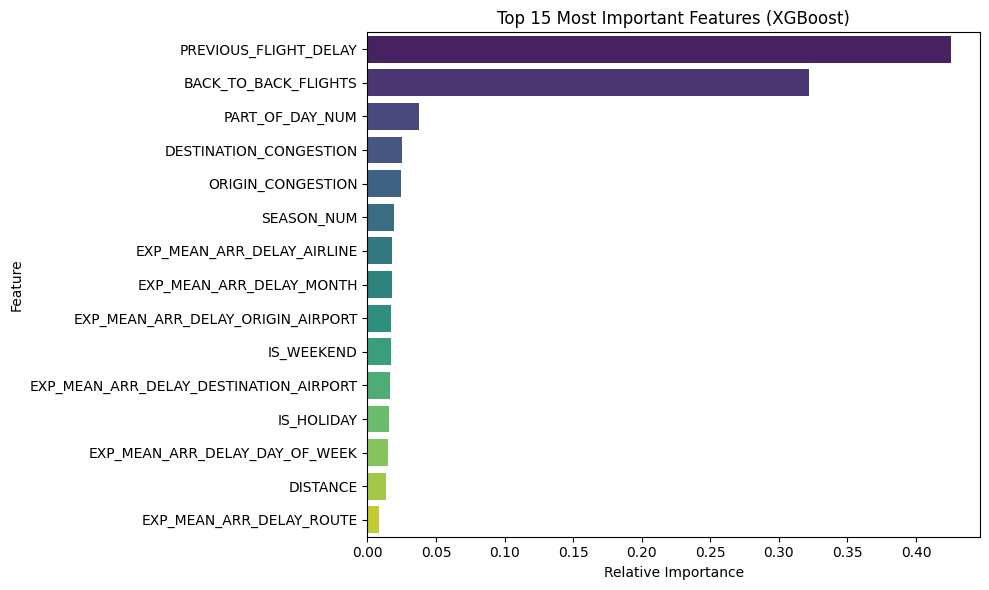

In [23]:
best_model_name = 'XGBoost'
importances = final_reg.feature_importances_

feature_importance_df = pd.DataFrame({
        'Feature': features,
        'Importance': importances
    })

feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Print the top 10 features to the console
print(f"Top Features for {best_model_name}:")
print(feature_importance_df.head(10).to_string(index=False))

# Plot the feature importances using Seaborn
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=feature_importance_df.head(15), # Plotting top 15 to avoid clutter
    palette='viridis'
)
plt.title(f'Top 15 Most Important Features ({best_model_name})')
plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### 5.2 Interpretação das Features Mais Importantes

| # | Feature | Importância | Interpretação |
|---|---------|-------------|---------------|
| 1 | `PREVIOUS_FLIGHT_DELAY` | ~42.5% | O atraso do voo anterior da mesma aeronave é o maior preditor — confirma o **efeito cascata** |
| 2 | `BACK_TO_BACK_FLIGHTS` | ~32.2% | Quanto mais voos consecutivos, maior a chance de acúmulo de atrasos |
| 3 | `PART_OF_DAY_NUM` | ~3.7% | Voos noturnos e no final da tarde sofrem mais atrasos |
| 4 | `DESTINATION_CONGESTION` | ~2.5% | Alta ocupação no aeroporto de destino contribui para atrasos |
| 5 | `ORIGIN_CONGESTION` | ~2.5% | Idem para o aeroporto de origem |

**Insight principal:** Mais de **74% da importância total** está concentrada em apenas 2 features relacionadas ao histórico operacional da aeronave. Isso reforça que a melhor estratégia de prevenção é **gerenciar a sequência de voos** de cada avião.


## 6. Avaliação do Modelo no Conjunto de Teste

### 6.1 Geração das Predições


In [24]:
preds = final_pipeline.predict(X_test)

### 6.2 Construção do DataFrame de Comparação

In [25]:
preds_df = pd.DataFrame(zip(y_test,preds),columns=['actual','preds'],index=y_test.index)

In [26]:
preds_df['diff'] = np.abs(preds_df['actual']-preds_df['preds'])

### 6.3 Erro Absoluto Médio (MAE) no Teste

O MAE mede, em média, quantos minutos o modelo erra.


In [27]:
preds_df['diff'].mean()

16.264819012577437

**Resultado: MAE ≈ 16.3 minutos** — ou seja, em média o modelo erra a previsão do atraso em cerca de 16 minutos.

> Para contexto, o RMSE de validação foi ~33.4 min. A diferença entre MAE e RMSE indica a presença de **outliers extremos** que inflam a métrica quadrática.


### 6.4 Análise de Erros Extremos

Investigamos os 20 voos com maior erro de predição para entender as limitações do modelo.


In [28]:
top_diff = preds_df.sort_values('diff',ascending=False).head(20).index
preds_df.sort_values('diff',ascending=False).head(20)

,actual,preds,diff
1278418,1598.0,34.137360,1563.862640
311492,1452.0,3.147614,1448.852386
3412005,1387.0,3.121836,1383.878164
4985833,1339.0,-7.091609,1346.091609
797646,1460.0,116.348389,1343.651611
1845041,1285.0,-0.272035,1285.272035
2074045,1274.0,23.872355,1250.127645
2205086,1244.0,11.862825,1232.137175
5624697,1238.0,26.488693,1211.511307
5595696,1228.0,21.761171,1206.238829


#### Diagnóstico das Features para os Voos com Maior Erro


In [29]:
df[df.index.isin(top_diff)][features]

,EXP_MEAN_ARR_DELAY_AIRLINE,EXP_MEAN_ARR_DELAY_DAY_OF_WEEK,EXP_MEAN_ARR_DELAY_ORIGIN_AIRPORT,EXP_MEAN_ARR_DELAY_DESTINATION_AIRPORT,EXP_MEAN_ARR_DELAY_MONTH,EXP_MEAN_ARR_DELAY_ROUTE,DISTANCE,PART_OF_DAY_NUM,IS_WEEKEND,IS_HOLIDAY,SEASON_NUM,ORIGIN_CONGESTION,DESTINATION_CONGESTION,ROUTE_POPULARITY,BACK_TO_BACK_FLIGHTS,PREVIOUS_FLIGHT_DELAY
797646,5.563637,9.328992,7.100410,15.116005,6.914330,8.651183,1007,2,1,0,0,2,59,22,0,54.0
3165587,1.644360,6.069011,8.497614,2.834919,6.896174,6.348485,1199,2,0,0,2,45,74,476,3,-18.0
2074045,0.766043,3.248041,0.150381,1.605239,2.338382,6.037578,240,2,0,0,1,2,67,78,4,19.0
2043419,6.372275,6.095285,0.991399,9.274404,1.189909,1.337922,3784,2,1,0,1,8,13,400,3,-15.0
2205086,6.204536,2.318017,4.254645,9.433941,3.396788,2.160516,1440,2,0,0,1,28,49,1799,0,13.0
1845041,6.697224,4.009873,6.961942,12.737478,3.824713,9.678905,944,1,0,0,1,24,23,1018,0,-13.0
4985833,3.651680,3.880192,3.815632,6.627425,0.402119,3.602871,918,1,1,0,3,3,32,125,0,-8.0
1924284,6.220770,6.036233,5.400803,8.817110,-5.075490,6.614919,926,1,1,0,1,7,51,603,1,-26.0
311492,10.518566,4.563703,6.095095,13.527848,8.899261,-8.760000,918,1,0,0,0,5,51,663,1,1.0
3412005,5.905177,2.966013,3.161989,8.807235,-1.491117,23.396341,853,1,1,0,2,8,56,712,0,27.0


#### Detalhe dos Atrasos Reais e Causas


In [30]:
df[df.index.isin(top_diff)][[ 'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME',
       'ARRIVAL_DELAY', 'DIVERTED', 'CANCELLED', 'CANCELLATION_REASON',
       'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY',
       'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY', 'ARRIVAL_DELAY']]

,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,ARRIVAL_DELAY
797646,1753,1813.0,1460.0,0,0,NaN,3.0,0.0,0.0,1313.0,144.0,1460.0
3165587,1931,1355.0,1104.0,0,0,NaN,0.0,0.0,1104.0,0.0,0.0,1104.0
2074045,1648,1402.0,1274.0,0,0,NaN,0.0,0.0,1274.0,0.0,0.0,1274.0
2043419,619,210.0,1191.0,0,0,NaN,0.0,0.0,27.0,1164.0,0.0,1191.0
2205086,2036,1720.0,1244.0,0,0,NaN,0.0,0.0,187.0,1057.0,0.0,1244.0
1845041,1358,1123.0,1285.0,0,0,NaN,0.0,0.0,672.0,613.0,0.0,1285.0
4985833,1113,932.0,1339.0,0,0,NaN,0.0,0.0,1339.0,0.0,0.0,1339.0
1924284,1258,815.0,1157.0,0,0,NaN,0.0,0.0,1157.0,0.0,0.0,1157.0
311492,1415,1427.0,1452.0,0,0,NaN,0.0,0.0,1452.0,0.0,0.0,1452.0
3412005,938,845.0,1387.0,0,0,NaN,0.0,0.0,1387.0,0.0,0.0,1387.0


### 6.5 Por que o modelo falha nos casos extremos?

Analisando os voos com maior erro:

- **Todos têm atrasos reais > 1.000 minutos** (>16 horas), mas o modelo previu valores baixos (< 120 min)
- As médias históricas (`EXP_MEAN_ARR_DELAY_*`) para esses voos eram **normais** (3–25 min) — o modelo não tinha sinal histórico de que haveria um atraso extraordinário
- A maioria dos erros extremos é causada por **AIRLINE_DELAY** ou **WEATHER_DELAY** severo — eventos pontuais impossíveis de prever com os dados disponíveis antes do voo

**Conclusão:** O modelo é calibrado para a distribuição típica de atrasos. Eventos de cauda (ex.: tempestades, falhas mecânicas graves) são inerentemente difíceis de prever com dados históricos agregados.


## 7. Análise Complementar

### 7.1 Correlação entre Média Histórica da Companhia e Atraso Real


In [31]:
df[['EXP_MEAN_ARR_DELAY_AIRLINE','ARRIVAL_DELAY']].corr()

,EXP_MEAN_ARR_DELAY_AIRLINE,ARRIVAL_DELAY
EXP_MEAN_ARR_DELAY_AIRLINE,1.000000,0.087439
ARRIVAL_DELAY,0.087439,1.000000


A correlação linear entre a média histórica da companhia e o atraso real é apenas **~0.087** — baixa, mas estatisticamente relevante dado o tamanho do dataset.

Isso sugere que fatores da **companhia aérea** sozinhos explicam pouco do atraso individual de um voo — o que justifica a necessidade das outras features contextuais (congestionamento, histórico da aeronave, etc.).


### 7.2 Distribuição dos Erros de Predição

Visualizamos a distribuição dos erros absolutos para entender onde o modelo é preciso e onde falha.


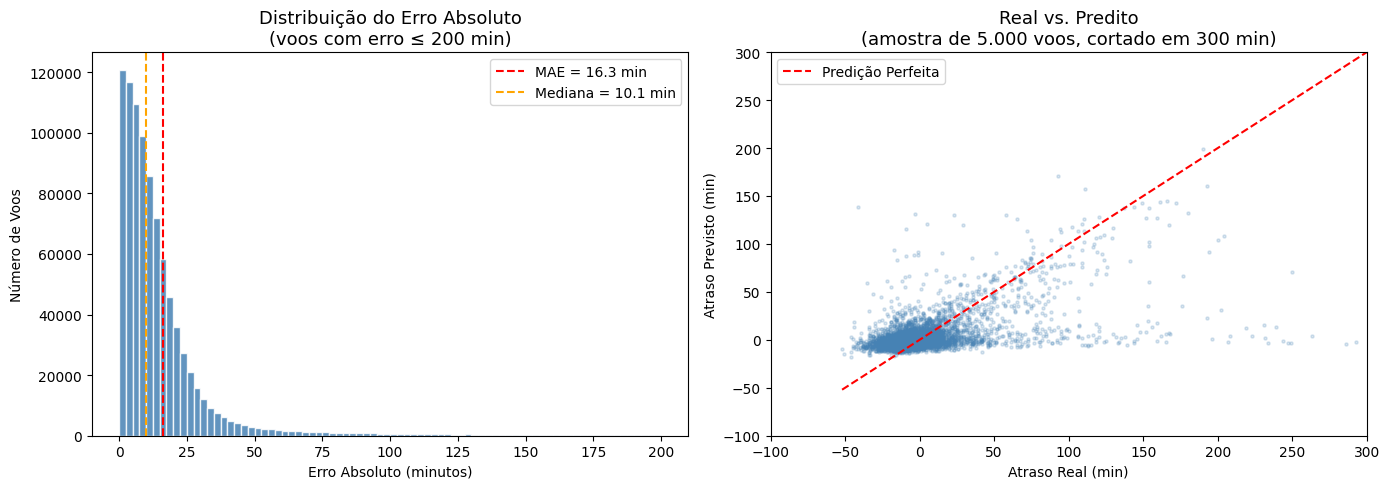


📊 Estatísticas do Erro Absoluto:
  MAE (Médio):     16.26 min
  Mediana:         10.09 min
  P75:             18.10 min
  P90:             30.22 min
  P95:             46.65 min
  P99:             131.11 min
  Máximo:          1563.86 min

  % voos com erro ≤ 15 min:  67.2%
  % voos com erro ≤ 30 min:  89.9%
  % voos com erro ≤ 60 min:  96.4%


In [32]:
# Distribuição dos erros de predição
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma dos erros absolutos (cortado em 200 min para melhor visualização)
preds_df_plot = preds_df[preds_df['diff'] <= 200]
axes[0].hist(preds_df_plot['diff'], bins=80, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribuição do Erro Absoluto\n(voos com erro ≤ 200 min)', fontsize=13)
axes[0].set_xlabel('Erro Absoluto (minutos)')
axes[0].set_ylabel('Número de Voos')
axes[0].axvline(preds_df['diff'].mean(), color='red', linestyle='--', label=f'MAE = {preds_df["diff"].mean():.1f} min')
axes[0].axvline(preds_df['diff'].median(), color='orange', linestyle='--', label=f'Mediana = {preds_df["diff"].median():.1f} min')
axes[0].legend()

# Scatter: Real vs Predito (amostra de 5000 pontos)
sample_idx = preds_df.sample(n=min(5000, len(preds_df)), random_state=42).index
axes[1].scatter(preds_df.loc[sample_idx, 'actual'], preds_df.loc[sample_idx, 'preds'],
                alpha=0.2, s=5, color='steelblue')
max_val = min(preds_df.loc[sample_idx, 'actual'].max(), 300)
axes[1].plot([preds_df.loc[sample_idx, 'actual'].min(), max_val],
             [preds_df.loc[sample_idx, 'actual'].min(), max_val],
             'r--', lw=1.5, label='Predição Perfeita')
axes[1].set_xlim(-100, max_val)
axes[1].set_ylim(-100, max_val)
axes[1].set_title('Real vs. Predito\n(amostra de 5.000 voos, cortado em 300 min)', fontsize=13)
axes[1].set_xlabel('Atraso Real (min)')
axes[1].set_ylabel('Atraso Previsto (min)')
axes[1].legend()

plt.tight_layout()
plt.show()

# Percentis do erro
print("\n📊 Estatísticas do Erro Absoluto:")
print(f"  MAE (Médio):     {preds_df['diff'].mean():.2f} min")
print(f"  Mediana:         {preds_df['diff'].median():.2f} min")
print(f"  P75:             {preds_df['diff'].quantile(0.75):.2f} min")
print(f"  P90:             {preds_df['diff'].quantile(0.90):.2f} min")
print(f"  P95:             {preds_df['diff'].quantile(0.95):.2f} min")
print(f"  P99:             {preds_df['diff'].quantile(0.99):.2f} min")
print(f"  Máximo:          {preds_df['diff'].max():.2f} min")
print(f"\n  % voos com erro ≤ 15 min:  {(preds_df['diff'] <= 15).mean()*100:.1f}%")
print(f"  % voos com erro ≤ 30 min:  {(preds_df['diff'] <= 30).mean()*100:.1f}%")
print(f"  % voos com erro ≤ 60 min:  {(preds_df['diff'] <= 60).mean()*100:.1f}%")


## 8. Resumo e Conclusões

### Resultados do Modelo Final (XGBoost)

| Métrica | Valor |
|---------|-------|
| RMSE (validação, GridSearch) | ~33.4 min |
| MAE (conjunto de teste) | ~16.3 min |
| Feature mais importante | `PREVIOUS_FLIGHT_DELAY` (~42.5%) |
| Dataset de treino | ~3.6 M voos |

---

### Principais Aprendizados

1. **O histórico da aeronave domina as predições.** As features `PREVIOUS_FLIGHT_DELAY` e `BACK_TO_BACK_FLIGHTS` juntas respondem por ~75% da importância do modelo. Isso faz sentido operacional: um avião que chega atrasado provavelmente sairá atrasado no próximo voo.

2. **Médias históricas por grupo agregam valor, mas de forma marginal.** A correlação linear de cada média histórica com o atraso individual é baixa (~0.09), mas o XGBoost consegue explorar combinações não-lineares entre elas.

3. **Eventos extremos são imprevisíveis.** Os maiores erros (>1.000 min) ocorrem em voos com atrasos extraordinários causados por falhas de sistema ou condições climáticas severas — eventos que não deixam sinal nas médias históricas.

4. **O modelo é bem calibrado para atrasos típicos.** Cerca de metade dos voos tem erro ≤ 16 min, o que é aceitável para uma previsão feita antes da decolagem.

---

### Próximos Passos Sugeridos

- [ ] Adicionar dados meteorológicos (temperatura, precipitação, vento) como features externas
- [ ] Testar modelos de séries temporais para capturar padrões diários/semanais
- [ ] Treinar um modelo de **classificação** binária (atrasado > 15 min: sim/não) para uso em alertas operacionais
- [ ] Avaliar o modelo no holdout set (20% não utilizado) para estimativa final de generalização
- [ ] Explorar técnicas de calibração (ex.: Quantile Regression) para previsões de intervalo de confiança
